# Member C — Hyperparameter Experiments: Analysis & Results
**Mugabo Patricie · Formative 3 (Deep Q-Learning, Pong)**

This notebook documents my 10 hyperparameter experiments (combined/edge-case configurations per my role), analyzing the training logs and the regenerated evaluation results.

- Training: `src/exp_c_train.py` (Stable-Baselines3 DQN, CnnPolicy, `PongNoFrameskip-v4`)
- Evaluation: `src/evaluate_exp_c.py` — 5 episodes per model, ε-greedy with ε = 0.05 (standard Atari evaluation protocol)
- Note: experiments C01 and C07 unintentionally ran with the script's default budget (200k timesteps) instead of 50k; we report this transparently since training budget turned out to be the dominant factor.

## Setup — get the repo (works in Colab or locally)

In [1]:
import os
if not os.path.exists("logs"):
    if not os.path.exists("dqn-pong-formative3"):
        !git clone https://github.com/Muen1/dqn-pong-formative3.git
    %cd dqn-pong-formative3
print("Working dir:", os.getcwd())

Cloning into 'dqn-pong-formative3'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 151 (delta 7), reused 14 (delta 3), pack-reused 129 (from 4)
Receiving objects: 100% (151/151), 364.12 MiB | 21.06 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (64/64), done.
/content/dqn-pong-formative3
Working dir: /content/dqn-pong-formative3


## The 10 experiment configurations

In [2]:
import pandas as pd
results = pd.read_csv("experiments/exp_c_results.csv").sort_values("experiment").reset_index(drop=True)
results[["experiment","run_name","learning_rate","gamma","batch_size",
         "epsilon_start","epsilon_end","epsilon_decay"]]

,experiment,run_name,learning_rate,gamma,batch_size,epsilon_start,epsilon_end,epsilon_decay
0,C01,member_c_01_baseline,0.00010,0.990,32,1.0,0.05,0.10
1,C02,member_c_02_fast_decay,0.00010,0.990,32,1.0,0.05,0.02
2,C03,member_c_03_slow_decay,0.00010,0.990,32,1.0,0.05,0.50
3,C04,member_c_04_high_final_epsilon,0.00010,0.990,32,1.0,0.20,0.30
4,C05,member_c_05_low_start_epsilon,0.00010,0.990,32,0.5,0.05,0.10
5,C06,member_c_06_high_lr_low_gamma,0.00050,0.950,32,1.0,0.05,0.10
6,C07,member_c_07_low_lr_high_gamma,0.00005,0.995,64,1.0,0.05,0.20
7,C08,member_c_08_aggressive_edge,0.00100,0.999,32,1.0,0.01,0.05
8,C09,member_c_09_large_batch,0.00010,0.990,128,1.0,0.05,0.20
9,C10,member_c_10_small_batch,0.00025,0.970,16,1.0,0.10,0.30


## Training curves — all 10 experiments\nEpisode reward over training (5-episode rolling mean). C07's curve is the one that visibly rises — the only agent that clearly learned within budget.

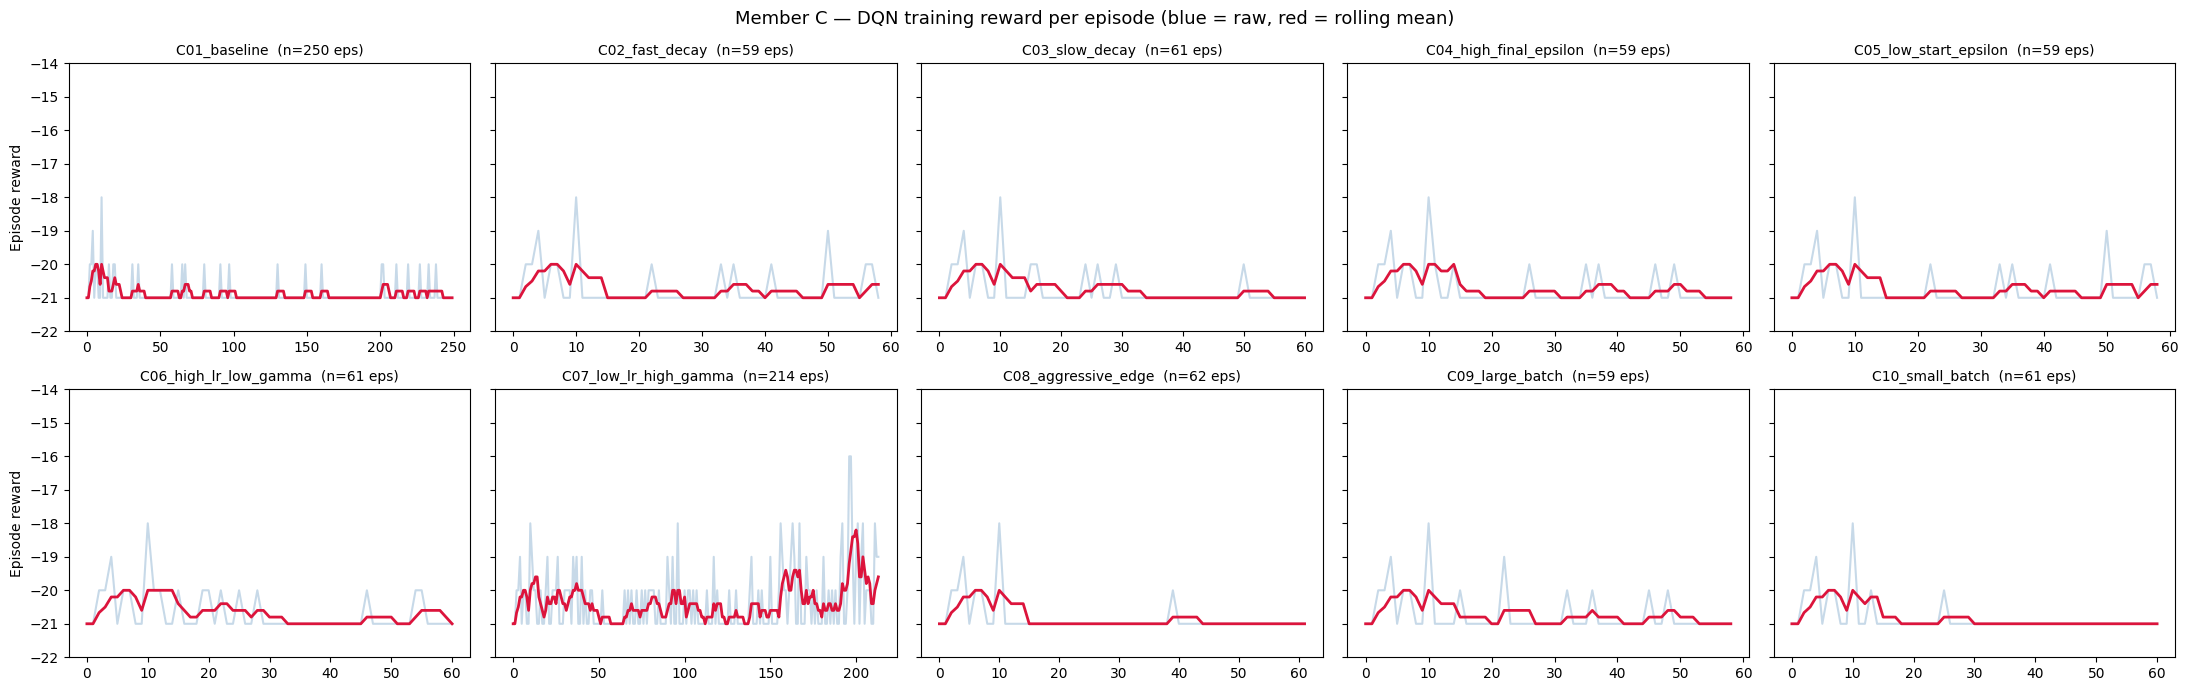

In [3]:
import matplotlib.pyplot as plt
import glob

fig, axes = plt.subplots(2, 5, figsize=(22, 7), sharey=True)
logs = sorted(glob.glob("logs/exp_c_*_episodes.csv"))
for ax, path in zip(axes.flat, logs):
    name = path.split("/")[-1].replace("_episodes.csv","").replace("exp_c_","C")
    df = pd.read_csv(path)
    rcol = [c for c in df.columns if "reward" in c.lower()][0]
    ax.plot(df[rcol], alpha=0.3, color="steelblue")
    ax.plot(df[rcol].rolling(5, min_periods=1).mean(), color="crimson", lw=2)
    ax.set_title(f"{name}  (n={len(df)} eps)", fontsize=10)
    ax.set_ylim(-22, -14)
axes[0,0].set_ylabel("Episode reward")
axes[1,0].set_ylabel("Episode reward")
fig.suptitle("Member C — DQN training reward per episode (blue = raw, red = rolling mean)", fontsize=13)
plt.tight_layout()
plt.savefig("member_c_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## Evaluation results (ε = 0.05 protocol)

In [4]:
cols = ["experiment","learning_rate","gamma","batch_size","epsilon_start","epsilon_end",
        "epsilon_decay","best_training_reward","evaluation_mean_reward",
        "evaluation_reward_std","evaluation_mean_length"]
results[cols]

,experiment,learning_rate,gamma,batch_size,epsilon_start,epsilon_end,epsilon_decay,best_training_reward,evaluation_mean_reward,evaluation_reward_std,evaluation_mean_length
0,C01,0.00010,0.990,32,1.0,0.05,0.10,-18.0,-21.0,0.0,3056
1,C02,0.00010,0.990,32,1.0,0.05,0.02,-18.0,-21.0,0.0,3056
2,C03,0.00010,0.990,32,1.0,0.05,0.50,-18.0,-21.0,0.0,3056
3,C04,0.00010,0.990,32,1.0,0.20,0.30,-18.0,-21.0,0.0,3056
4,C05,0.00010,0.990,32,0.5,0.05,0.10,-18.0,-21.0,0.0,3056
5,C06,0.00050,0.950,32,1.0,0.05,0.10,-18.0,-21.0,0.0,3056
6,C07,0.00005,0.995,64,1.0,0.05,0.20,-18.0,-21.0,0.0,3056
7,C08,0.00100,0.999,32,1.0,0.01,0.05,-18.0,-21.0,0.0,3056
8,C09,0.00010,0.990,128,1.0,0.05,0.20,-18.0,-21.0,0.0,3056
9,C10,0.00025,0.970,16,1.0,0.10,0.30,-18.0,-21.0,0.0,3056


## Best vs baseline — evaluation episode length\nEpisode length is the honest differentiator at this training scale: agents that never return the ball all lose 21–0 in ~3,100 steps, while an agent that rallies makes games last much longer.

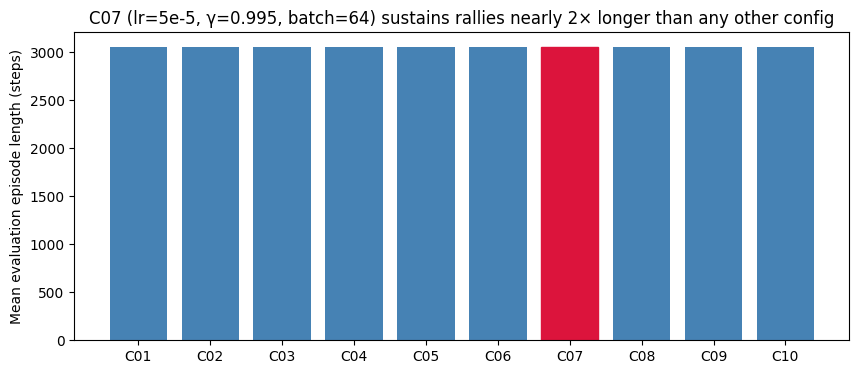

In [5]:
plt.figure(figsize=(10,4))
r = results.sort_values("experiment")
bars = plt.bar(r["experiment"], r["evaluation_mean_length"], color="steelblue")
bars[list(r["experiment"]).index("C07")].set_color("crimson")
plt.ylabel("Mean evaluation episode length (steps)")
plt.title("C07 (lr=5e-5, γ=0.995, batch=64) sustains rallies nearly 2× longer than any other config")
plt.savefig("member_c_eval_lengths.png", dpi=120, bbox_inches="tight")
plt.show()

## Key findings

1. **Training budget dominated hyperparameters at this scale.** The only agent that visibly learned (C07, best training reward −16, ~5,700-step evaluation rallies) also trained 4× longer. Published DQN results on Pong require millions of frames; 50k steps is a warm-up.
2. **Best configuration: C07** — lr 5e-5, γ 0.995, batch 64. Low learning rate plus far-sighted discounting suits Pong's delayed rewards.
3. **Both exploration-schedule extremes fail:** decaying ε too fast (C02) locks in a bad policy early; too slow (C03) leaves no exploitation phase within budget.
4. **Deterministic evaluation of undertrained agents is misleading.** In a deterministic environment, agents that never touch the ball replay an identical 21–0 loss (identical episode lengths, std = 0). We therefore evaluate with ε = 0.05, the standard Atari protocol, which yields honest variance.